# REGRESSIE

In [50]:
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor,RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVR


## Training/test set

In [6]:
df_all = pd.read_csv('goedeoutput.csv')

In [7]:
df_all = df_all.drop_duplicates(subset='file')
df_all.head()

,time,x,y,z,abs,file,roadtype,weight,weather,makers,...,z_std,x_mean,y_mean,z_mean,x_rms,y_rms,z_rms,x_spectral_flatness,y_spectral_flatness,z_spectral_flatness
0,0.005770,-0.388200,-0.164216,0.007704,0.421575,Asfalt_0_second_0.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.140477,0.067120,-0.002247,-0.004070,0.377403,0.168550,0.139825,0.522432,0.731454,0.653138
99,1.000646,-0.180555,0.701490,-0.055554,0.726481,Asfalt_0_second_1.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.575868,-0.722286,0.550876,-0.085218,2.287180,1.333847,0.579284,0.464260,0.505939,0.574400
199,2.005570,-4.626964,-1.482370,0.379587,4.873428,Asfalt_0_second_2.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.916088,0.911198,0.238479,-0.170147,2.528798,1.360446,0.927195,0.531467,0.642817,0.745212
298,3.000444,3.016697,0.947292,-0.673180,3.232800,Asfalt_0_second_3.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.862473,-0.349491,-0.364454,-0.061719,3.426488,1.298304,0.860367,0.396479,0.540455,0.702190
398,4.005364,-0.492856,1.994679,0.532708,2.122600,Asfalt_0_second_4.csv,asphalt,0.0,Dry,Laurence & Doris,...,0.736694,0.466448,0.398065,-0.107084,2.216413,1.032676,0.740745,0.466821,0.642661,0.828434


In [8]:
colomn_names = df_all.columns
colomn_names

# colomnen verwijderen
feature_names=['time', 'x', 'y', 'z', 'abs', 'roadtype', 'weather',
       'x_std', 'z_std', 'x_mean',
       'x_rms', 'z_rms',
       'z_spectral_flatness']
Y = df_all['weight']
X = df_all[feature_names]
X = pd.get_dummies(X, columns=['weather','roadtype'], drop_first=True, dtype=int)
#Y = pd.get_dummies(Y, columns=['roadtype'], drop_first=True, dtype=int)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## model

In [10]:
model = GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [16]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results_df.head()) 

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print(r2)
print(f"nModel Accuracy: {rmse:.4f}")

        Actual  Predicted
67954     2.60   1.317612
108359    1.75   2.268509
5439      1.50   0.989513
74331     2.60   2.499349
51950     0.40   0.878211
0.1347268346528211
nModel Accuracy: 1.5714


In [42]:
Y.unique()

array([0.  , 0.5 , 1.  , 1.5 , 2.  , 0.4 , 0.9 , 2.6 , 4.6 , 0.75, 1.75,
       2.75, 3.75, 5.75])

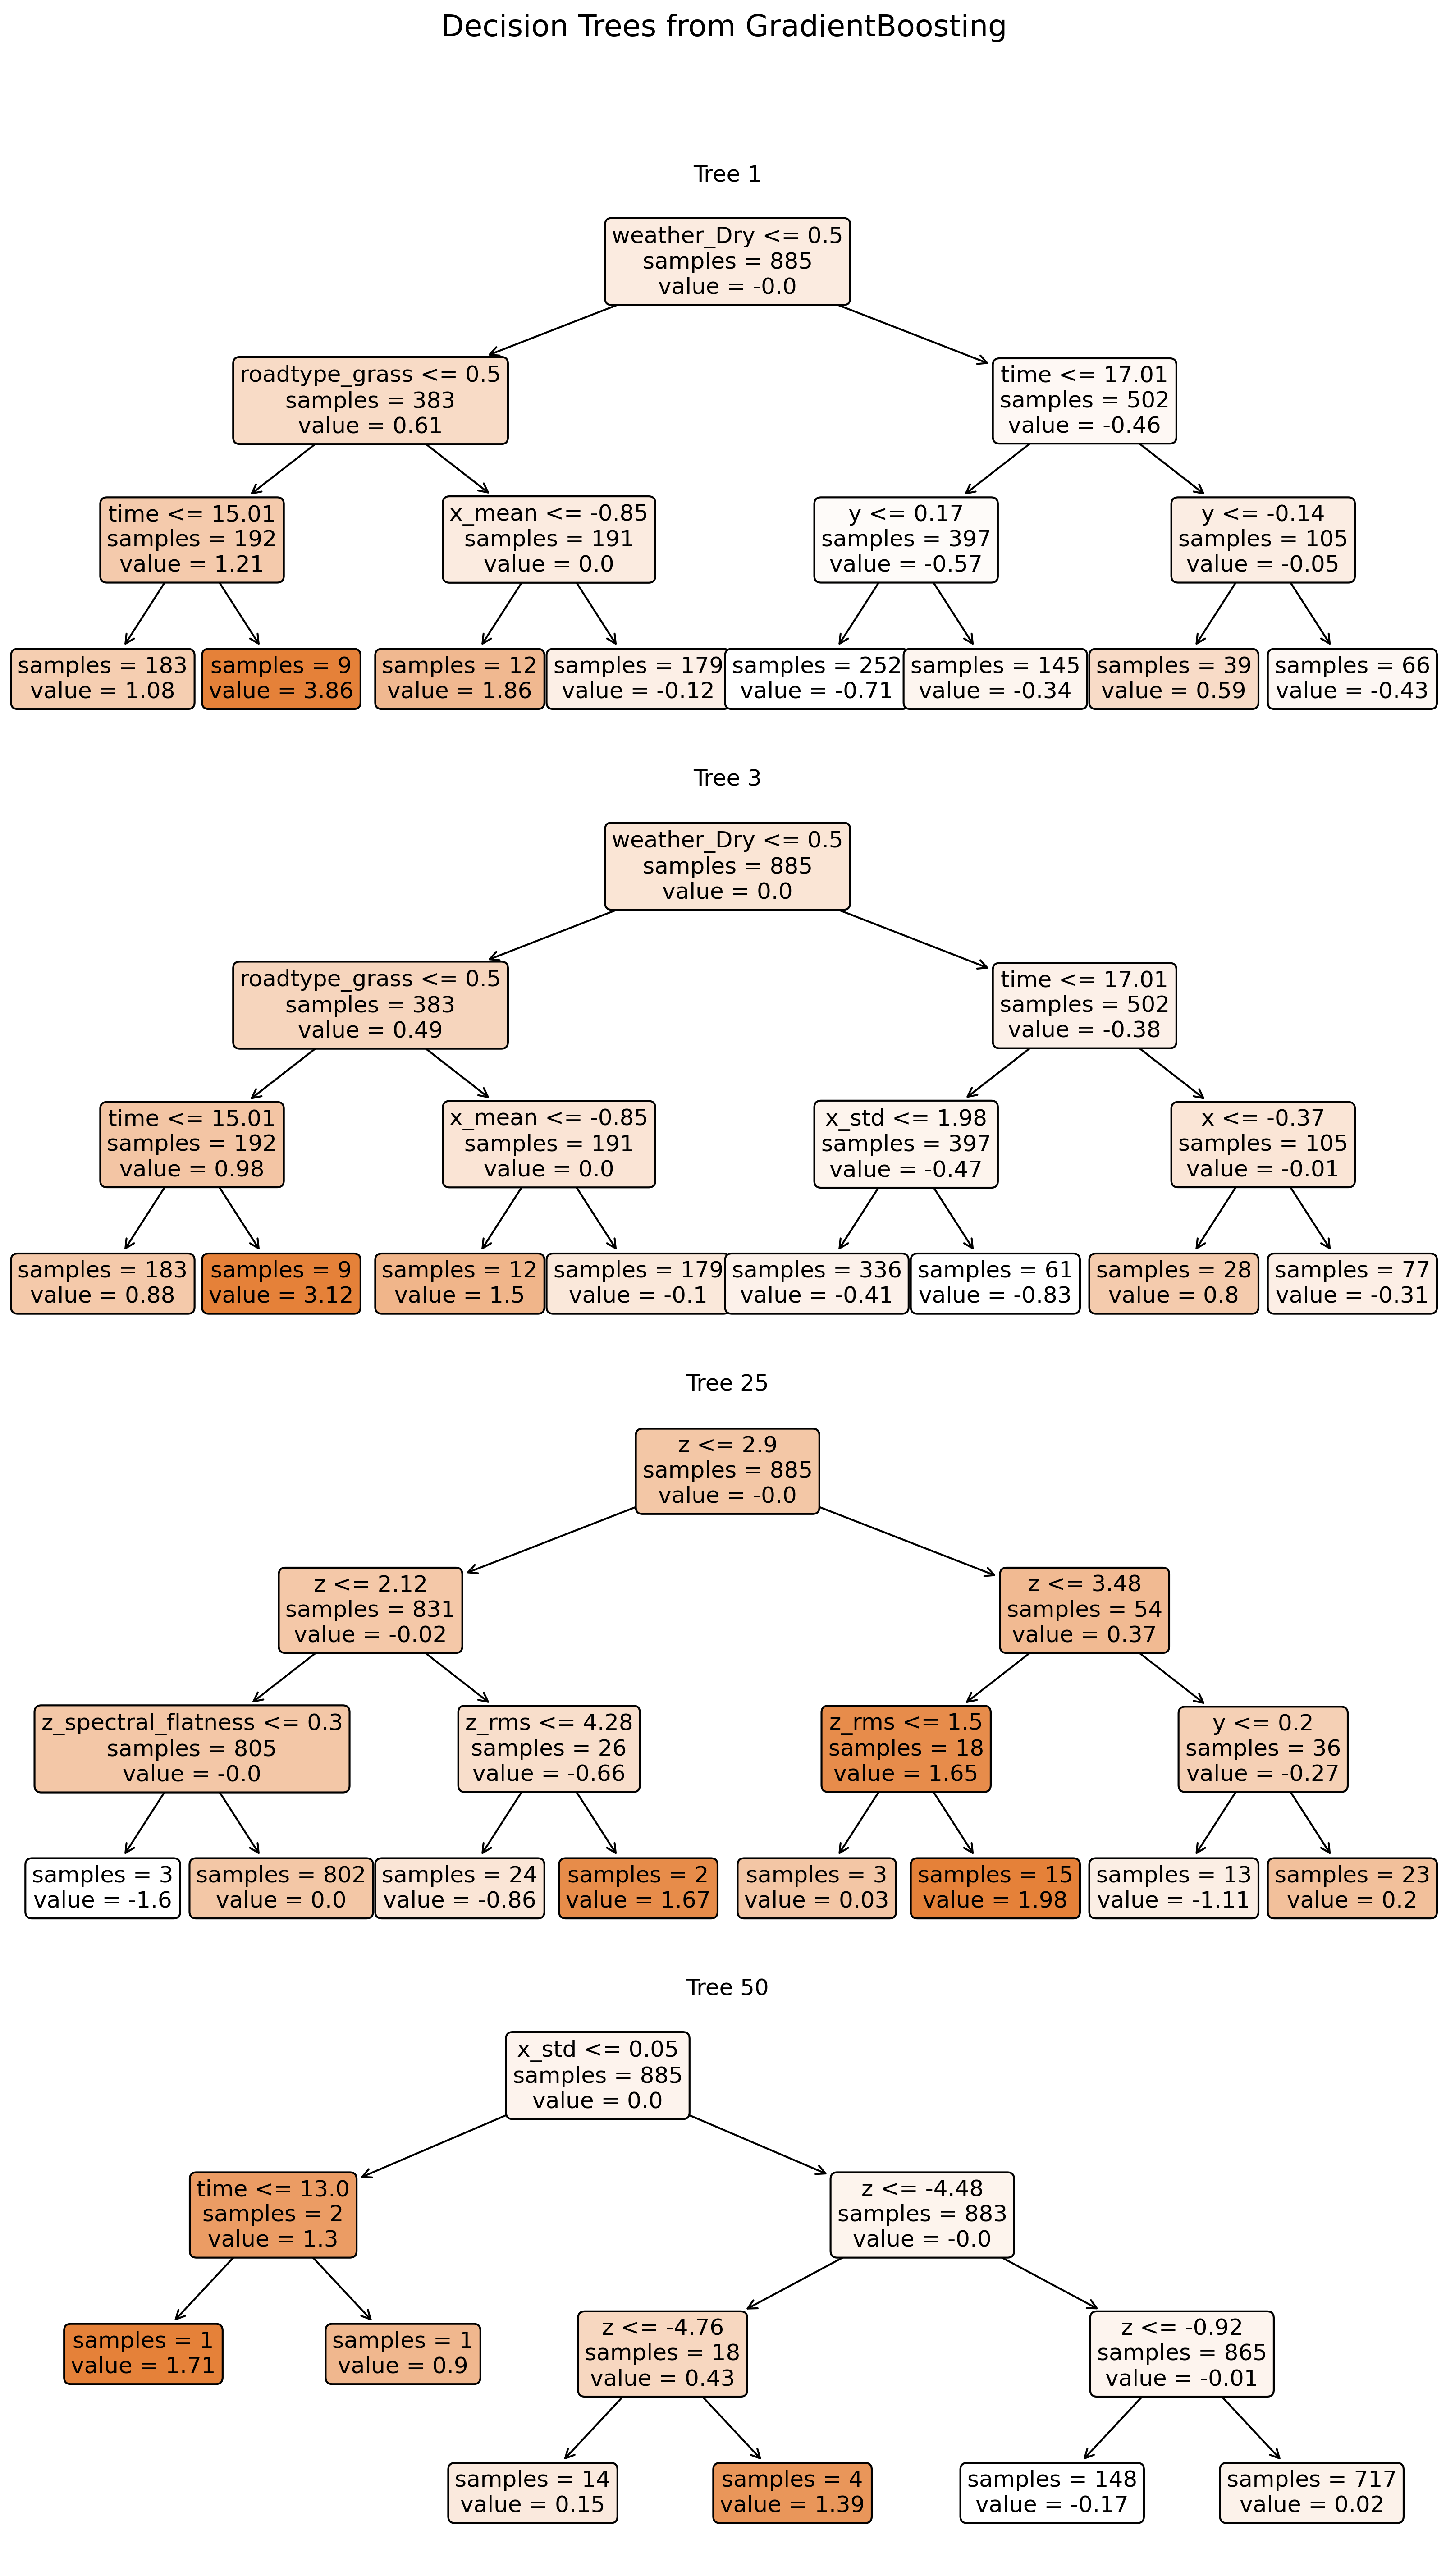

In [11]:
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 2, 24, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(model.estimators_[tree_idx,0], 
              feature_names=x_train.columns,
              impurity=False,
              filled=True, 
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

https://towardsdatascience.com/gradient-boosting-regressor-explained-a-visual-guide-with-code-examples-c098d1ae425c/

## met gridsearch

### duurt minimaal 46min en 44.4 seconden dus wees voorzichting met runnen

In [ ]:
pipeline = make_pipeline(StandardScaler(), GradientBoostingRegressor()) #max_iter=1000, tol=1e-3))

param_grid = {
    'gradientboostingregressor__loss': ['squared_error', 'absolute_error'],
    'gradientboostingregressor__learning_rate': [0.001, 0.01, 0.1, 0.2],
    'gradientboostingregressor__n_estimators': [50, 100, 200],
    'gradientboostingregressor__max_depth': [2, 3, 4],
    'gradientboostingregressor__min_samples_split': [2, 5],
    'gradientboostingregressor__min_samples_leaf': [1,2],
    'gradientboostingregressor__subsample': [0.8,1]


}
grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)


Fitting 7 folds for each of 576 candidates, totalling 4032 fits
[CV] END gradientboostingregressor__learning_rate=0.001, gradientboostingregressor__loss=squared_error, gradientboostingregressor__max_depth=2, gradientboostingregressor__min_samples_leaf=1, gradientboostingregressor__min_samples_split=2, gradientboostingregressor__n_estimators=50, gradientboostingregressor__subsample=0.8; total time=   0.1s
[CV] END gradientboostingregressor__learning_rate=0.001, gradientboostingregressor__loss=squared_error, gradientboostingregressor__max_depth=2, gradientboostingregressor__min_samples_leaf=1, gradientboostingregressor__min_samples_split=2, gradientboostingregressor__n_estimators=50, gradientboostingregressor__subsample=0.8; total time=   0.1s
[CV] END gradientboostingregressor__learning_rate=0.001, gradientboostingregressor__loss=squared_error, gradientboostingregressor__max_depth=2, gradientboostingregressor__min_samples_leaf=1, gradientboostingregressor__min_samples_split=2, gradientb

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('gradientboostingregressor',
                                        GradientBoostingRegressor())]),
             n_jobs=1,
             param_grid={'gradientboostingregressor__learning_rate': [0.001,
                                                                      0.01, 0.1,
                                                                      0.2],
                         'gradientboostingregressor__loss': ['squared_error',
                                                             'absolute_error'],
                         'gradientboostingregressor__max_depth': [2, 3, 4],
                         'gradientboostingregressor__min_samples_leaf': [1, 2],
                         'gradientboostingregressor__min_samples_split': [2, 5],
                         'gradientboostingregressor__n_estimators': [50, 100,
                                                                     200],
                         'gradientboostingregressor__subsample': [0.8, 1]},
             verbose=2)

In [39]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv.best_score_}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingregressor',
                 GradientBoostingRegressor(min_samples_split=5, n_estimators=50,
                                           subsample=1))])
Leading to an accuracy of: 0.18087669159128278


In [44]:
grid_cv.best_params_

{'gradientboostingregressor__learning_rate': 0.1,
 'gradientboostingregressor__loss': 'squared_error',
 'gradientboostingregressor__max_depth': 3,
 'gradientboostingregressor__min_samples_leaf': 1,
 'gradientboostingregressor__min_samples_split': 5,
 'gradientboostingregressor__n_estimators': 50,
 'gradientboostingregressor__subsample': 1}

{'gradientboostingregressor__learning_rate': 0.1,
 'gradientboostingregressor__loss': 'squared_error',
 'gradientboostingregressor__max_depth': 3,
 'gradientboostingregressor__min_samples_leaf': 1,
 'gradientboostingregressor__min_samples_split': 5,
 'gradientboostingregressor__n_estimators': 50,
 'gradientboostingregressor__subsample': 1}

In [47]:
y_pred = grid_cv.best_estimator_.predict(x_test)

In [48]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results_df.head()) 

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print(r2)
print(f"nModel Accuracy: {rmse:.4f}")

        Actual  Predicted
67954     2.60   1.259202
108359    1.75   2.249709
5439      1.50   1.067321
74331     2.60   2.298187
51950     0.40   1.115757
0.140476264570912
nModel Accuracy: 1.5662


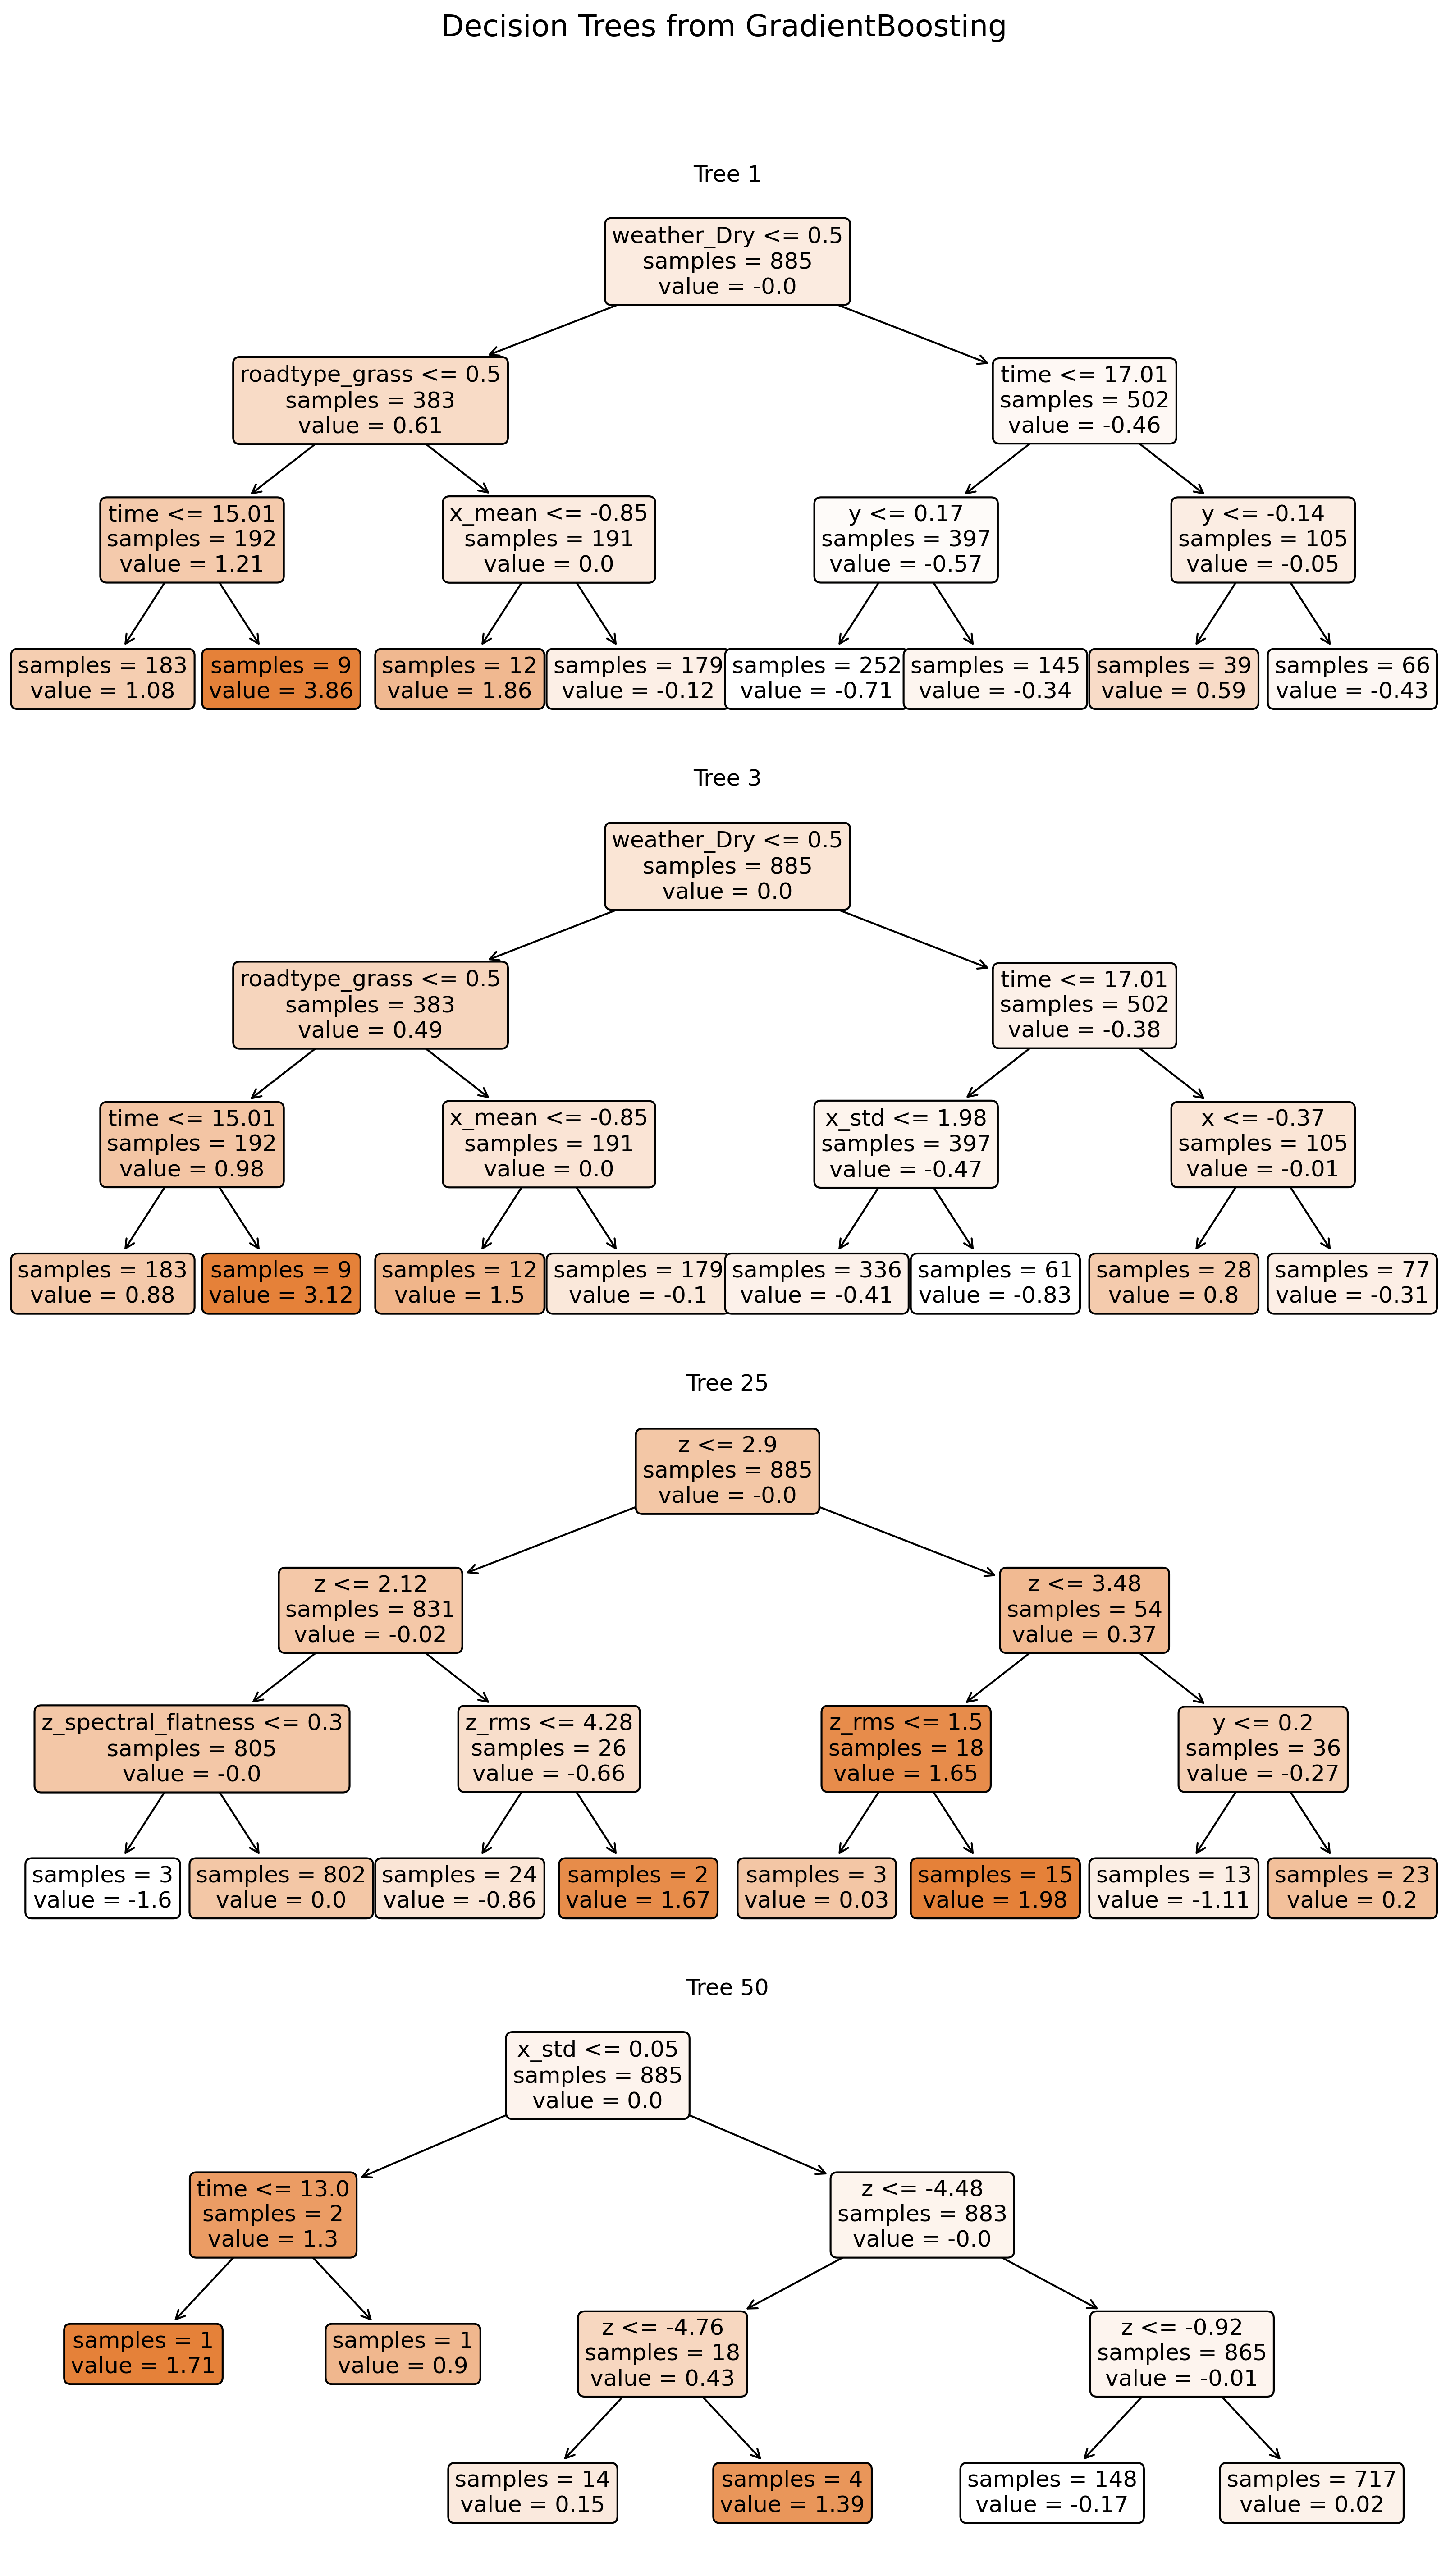

In [49]:
plt.figure(figsize=(11, 20), dpi=300)

for i, tree_idx in enumerate([0, 2, 24, 49]):
    plt.subplot(4, 1, i+1)
    plot_tree(model.estimators_[tree_idx,0], 
              feature_names=x_train.columns,
              impurity=False,
              filled=True, 
              rounded=True,
              precision=2,
              fontsize=12)
    plt.title(f'Tree {tree_idx + 1}')

plt.suptitle('Decision Trees from GradientBoosting', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## svr


In [56]:
pipeline = make_pipeline(StandardScaler(), SVR()) #max_iter=1000, tol=1e-3))

param_grid = {
    'svr__kernel': ['rbf'],
    'svr__C': [0.1, 1, 10],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma': ['scale', 0.1, 1]
}

grid_cv = GridSearchCV(pipeline, 
                       param_grid=param_grid,
                       n_jobs=1, 
                       cv=7, 
                       verbose=2) 

grid_cv.fit(x_train, y_train)


Fitting 7 folds for each of 27 candidates, totalling 189 fits
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=scale, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=0.1, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=0.1, svr__kernel=rbf; total time=   0.0s
[CV] END svr__C=0.1, svr__epsilon=0.01, svr__gamma=0.1, svr__kernel=rbf; total time=   0.0s
[CV]

GridSearchCV(cv=7,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('svr', SVR())]),
             n_jobs=1,
             param_grid={'svr__C': [0.1, 1, 10],
                         'svr__epsilon': [0.01, 0.1, 0.5],
                         'svr__gamma': ['scale', 0.1, 1],
                         'svr__kernel': ['rbf']},
             verbose=2)

In [57]:
print(f'For the training set, using K-fold CV the best estimator is: {grid_cv.best_estimator_}')
print(f'Leading to an accuracy of: {grid_cv.best_score_}')

For the training set, using K-fold CV the best estimator is: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=1, epsilon=0.5))])
Leading to an accuracy of: 0.10720593672391375


In [58]:
y_pred = grid_cv.best_estimator_.predict(x_test)

In [59]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print(results_df.head()) 

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print(r2)
print(f"nModel Accuracy: {rmse:.4f}")

        Actual  Predicted
67954     2.60   0.892969
108359    1.75   3.123800
5439      1.50   0.939510
74331     2.60   1.576237
51950     0.40   0.646659
0.10341836405251803
nModel Accuracy: 1.5996
